# Note to run this notebook:
A `.env` file at the root of this repository that defines `PYTHONPATH=src/python` is required to have the correct module resolution.

In [1]:
import polars as pl 

BKS = {
    "tsp": pl.read_csv("bks/tsp_bks.csv").with_columns(pl.concat_str(pl.col("instance"), pl.lit(".tsp")).alias("instance")),
    "csp": pl.read_csv("bks/csp_bks.csv"),
    "pdptw": pl.read_csv("bks/pdptw_bks.csv")
}

# Primal gap over time

In [ ]:
from typing import Literal
import matplotlib.pyplot as plt
import numpy as np
from results import Result


def primal_gaps_over_time(results: list[Result], tmax: float):
    gaps = []
    for r in results:
        g = []
        for t in range(int(tmax) + 1):
            g.append(r.primal_gap(t))
        gaps.append(g)
    return np.array(gaps)


def objective_over_time(results: list[Result], tmax: float):
    objs = []
    for r in results:
        o = []
        for t in range(int(tmax) + 1):
            obj = r.oot.at(t)
            if obj is None:
                obj = float("inf")
            o.append(obj)
        objs.append(o)
    return np.array(objs)


def plot_by_bandit(df: pl.DataFrame, tmax: float | None = None, metric: Literal["primal gap", "objective"] = "primal gap"):
    if tmax is None:
        max_timeout = df["timeout"].cast(pl.Float32).max()
        assert max_timeout is not None and isinstance(max_timeout, float)
        tmax = max_timeout
    # problem = df["instance"][0].split("/")[1]
    xs = np.arange(int(tmax) + 1)
    for name, bandit in df.group_by(pl.col("bandit")):
        results = [Result(**row) for row in bandit.iter_rows(named=True)]
        match metric:
            case "primal gap":
                arr = primal_gaps_over_time(results, tmax)
            case "objective":
                 arr = objective_over_time(results, tmax)
            case other:
                raise ValueError(f"Unknown metric {other}")
        mean, std = arr.mean(axis=0), arr.std(axis=0)
        ci95 = 1.96 * std / np.sqrt(arr.shape[0])
        plt.plot(xs, mean, label=name)
        plt.fill_between(xs, mean - ci95, mean + ci95, alpha=0.2)
        plt.xlabel("Time (s)")
        plt.ylabel("Primal gap")
        plt.margins(x=0.01, y=0.01)
    plt.legend()


# CSP

In [10]:
import polars as pl



df = pl.concat(
    [
        # pl.read_csv("logs/epsilongreedy-r2-csp/results.csv").with_columns(bandit=pl.lit("epsilongreedy-mlg")),
        # pl.read_csv("logs/ucb-r2-csp/results.csv").with_columns(bandit=pl.lit("ucb-mlg")),
        # pl.read_csv("logs/random-r2-csp/results.csv").with_columns(bandit=pl.lit("random-mlg")),
        # pl.read_csv("logs/dqn-no-target-csp_100/results.csv"),
        # pl.read_csv("logs/dqn-csp_100/results.csv"),
        # pl.read_csv("logs/2025-10-07T18-02-59.655674/results.csv").with_columns(bandit=pl.lit("dqn-no-target-optimized-wrong-params")),
        # pl.read_csv("logs/dqn-no-target-all/results.csv").with_columns(bandit=pl.lit("dqn-no-target-optimized")),
        # pl.read_csv("logs/random-python/results.csv").with_columns(bandit=pl.lit("random-python")),
        # pl.read_csv("logs/random-scala/results.csv").with_columns(bandit=pl.lit("random-scala")),
        # pl.read_csv("logs/dqn-no-target-300/results.csv").with_columns(bandit=pl.lit("dqn-no-target-300")),
        pl.read_csv("logs/ppo-csp500/results.csv").with_columns(bandit=pl.lit("best-ppo-500")),
        pl.read_csv("logs/random-csp500/results.csv").with_columns(bandit=pl.lit("random-500")),
    ],
    how="align",
)
df = df.filter(pl.col("reward") == "r2")
df.height

300

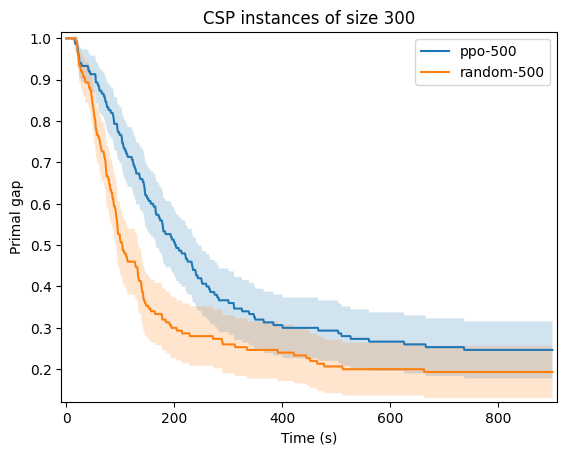

In [11]:
#with open("examples/csp/testingall-300.txt") as f:
#    instances = [line.strip() for line in f.readlines()]

#df_instances = df.filter(pl.col("instance").is_in(instances))
plot_by_bandit(df)
plt.title("CSP instances of size 500")
plt.show()
    


#with open("examples/csp/testingall-100.txt") as f:
#    instances = [line.strip() for line in f.readlines()]
#df = df.filter(pl.col("instance").is_in(instances))    
#plot_by_bandit(df, tmax=300)
#plt.ylim(0.1, 0.5)

In [10]:
y_axis = "bestObj"
x_axis = "bandit"
for (label, *_), group in df.group_by(x_axis):
    print(f"{label}: mean={group[y_axis].mean()}, std={group[y_axis].std()}")

dqn-no-target-300: mean=3.550724637681159, std=6.945115874307911
epsilongreedy-mlg: mean=2.75, std=5.384777466813619
random-mlg: mean=2.725, std=5.279266007963296
ucb-mlg: mean=2.7595238095238095, std=5.343663197110418


dqn-no-target-optimized 0.3815028901734104
dqn-no-target-optimized-wrong-params 0.37142857142857144


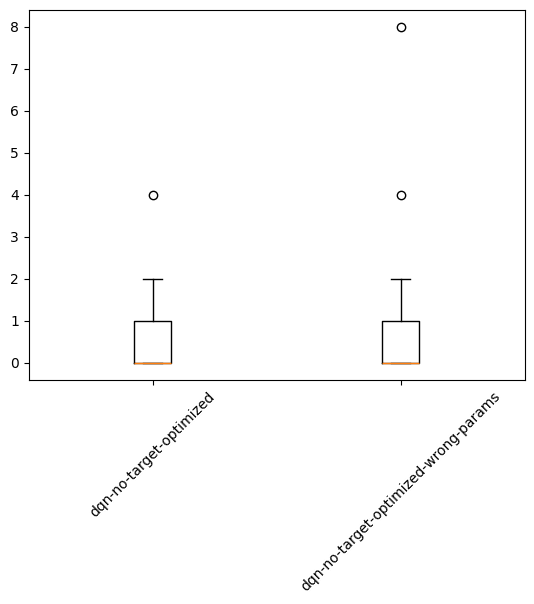

In [10]:
import matplotlib.pyplot as plt

col = "bestObj"
objs = []
labels = []
for (label, *_), group in df.group_by("bandit"):
    objs.append(group[col])
    labels.append(label)
    print(label, group[col].mean())
plt.boxplot(objs, tick_labels=labels)
# Rotate xticks by 45°
plt.xticks(rotation=45)
x=5

In [ ]:
to_concat = []
for path in filenames:
    df = pl.read_csv(path).filter((pl.col("bandit").is_in(reward_agnostic)) | (pl.col("reward") == reward))
    to_concat.append(df.select(pl.col("bandit"), pl.col("instance"), pl.col("solOverTime")))
df: pl.DataFrame = pl.concat(to_concat)

problem = df["instance"][0].split("/")[1]
xs = np.arange(int(tmax) + 1)
for name, bandit in df.group_by(pl.col("bandit")):
    match problem:
        case "csp":
            results = [CSPResult.parse(row) for row in bandit.iter_rows(named=True)]
        case "pdptw":
            results = [PDPTWResult.parse(row) for row in bandit.iter_rows(named=True)]
        case "tsp":
            results = [TSPResult.parse(row) for row in bandit.iter_rows(named=True)]
        case other:
            raise NotImplementedError(f"Not implemented for problem type: {other}")
    arr = primal_gaps_over_time(results, tmax)  # type: ignore
    mean, std = arr.mean(axis=0), arr.std(axis=0)
    ci95 = 1.96 * std / np.sqrt(arr.shape[0])
    plt.plot(xs, mean, label=name)
    plt.fill_between(xs, mean - ci95, mean + ci95, alpha=0.2)
    plt.xlabel("Time (s)")
    plt.ylabel("Primal gap")
    plt.margins(x=0.01, y=0.01)
    
    plt.legend()

## Analysis

In [6]:
import polars as pl
import os


def get_logs(directory: str):
    dfs = list[pl.DataFrame]()
    for file in os.listdir(directory):
        if not file.endswith("csv"):
            continue
        filename = os.path.join(directory, file)
        df = pl.read_csv(filename)
        if "loss" not in df.columns or "grad_norm" not in df.columns:
            df = df.with_columns(
                pl.lit(None, pl.Float32).alias("loss"),
                pl.lit(None, pl.Float32).alias("grad_norm"),
            )
        dfs.append(
            df.with_columns(
                (pl.col("timestamp_sec") - pl.col("timestamp_sec").min()).alias("t"),
                pl.col("loss").cast(pl.Float32),
                pl.col("grad_norm").cast(pl.Float32),
            )
        )
    return dfs


Text(0, 0.5, 'Loss')

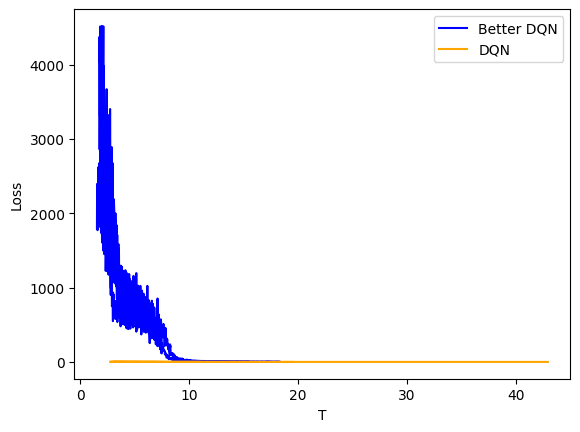

In [7]:
import matplotlib.pyplot as plt

x = "t"  # "t"
y = "loss"


for i, df in enumerate(get_logs("logs/2025-10-02T16-08-07.772033/csp-carseq_100_8_20_62/")):
    label = None
    if i == 0:
        label = "Better DQN"
    plt.plot(df[x], df[y], label=label, color="blue")
for i, df in enumerate(get_logs("logs/2025-10-03T09-00-02.784117/csp-carseq_100_8_20_62/")):
    label = None
    if i == 0:
        label = "DQN"
    plt.plot(df[x], df[y], label=label, color="orange")
    
plt.legend()
plt.xlabel(x.capitalize())
plt.ylabel(y.capitalize())

In [11]:
import polars as pl

INSTANCE = "carseq_100_8_20_62"
df = pl.read_csv("logs/2025-10-02T16-08-07.772033/results.csv").filter(pl.col("instance").str.contains(INSTANCE))
results_no_target = [CSPResult.parse(row) for row in df.iter_rows(named=True)]
df = pl.read_csv("logs/2025-10-03T09-00-02.784117/results.csv").filter(pl.col("instance").str.contains(INSTANCE))
results_target = [CSPResult.parse(row) for row in df.iter_rows(named=True)]

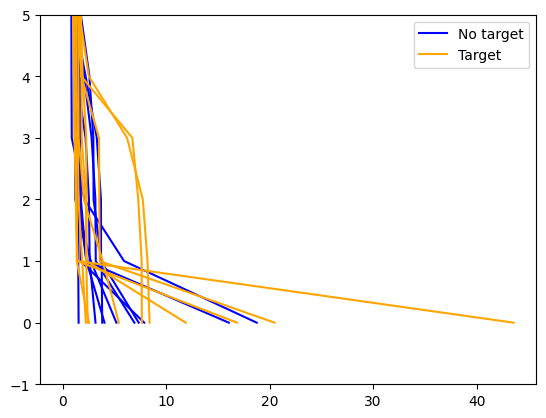

In [ ]:
import matplotlib.pyplot as plt

label = "No target"
for r in results_no_target:
    plt.plot(r.oot.timestamps, r.oot.objectives, color="blue", label=label)
    label = None

label = "Target"
for r in results_target:
    plt.plot(r.oot.timestamps, r.oot.objectives, color="orange", label=label)
    label = None
plt.ylim(-1, 5)
plt.legend()